In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Import Data

In [2]:
with open("./Data/train-images.idx3-ubyte", "rb") as image_file:
    image_header = image_file.read(16)
    image_bytes = image_file.read()

train_images = np.frombuffer(image_bytes, dtype=np.uint8).reshape(60000, 28, 28)

with open("./Data/train-labels.idx1-ubyte", "rb") as label_file:
    label_header = label_file.read(8)
    label_bytes = label_file.read()

train_labels = np.frombuffer(label_bytes, dtype=np.uint8)

In [3]:
print(f"train images: {train_images.shape}, train labels: {train_labels.shape}")

train images: (60000, 28, 28), train labels: (60000,)


In [4]:
with open("./Data/t10k-images.idx3-ubyte", "rb") as image_file:
    image_header = image_file.read(16)
    image_bytes = image_file.read()

test_images = np.frombuffer(image_bytes, dtype=np.uint8).reshape(10000, 28, 28)

with open("./Data/t10k-labels.idx1-ubyte", "rb") as label_file:
    label_header = label_file.read(8)
    label_bytes = label_file.read()

test_labels = np.frombuffer(label_bytes, dtype=np.uint8)

In [5]:
print(f"test images: {test_images.shape}, test labels: {test_labels.shape}")

test images: (10000, 28, 28), test labels: (10000,)


In [6]:
def preprocess_binary_data(images, labels):
    flattened_images = images.reshape(images.shape[0], -1)
    normalized_images = flattened_images / 255.0
    selected_mask = (labels == 0) | (labels == 1)

    return normalized_images[selected_mask], labels[selected_mask]


train_images_lr, train_labels_lr = preprocess_binary_data(
    train_images, train_labels
)
test_images_lr, test_labels_lr = preprocess_binary_data(test_images, test_labels)

In [7]:
print(
    f"train images: {train_images_lr.shape}, "
    f"train labels: {train_labels_lr.shape}"
)

print(
    f"test images: {test_images_lr.shape}, "
    f"test labels: {test_labels_lr.shape}"
)

train images: (12665, 784), train labels: (12665,)
test images: (2115, 784), test labels: (2115,)


### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train and evaluating (precision, recall, f1) the Logistic Regression model using the Gradient Descent approach **to classify 0 and 1 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [8]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-9
        return -np.mean(
            y_true * np.log(y_pred + epsilon)
            + (1 - y_true) * np.log(1 - y_pred + epsilon)
        )

    def fit(self, features, labels):
        n_samples, n_features = features.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            linear_output = np.dot(features, self.weights) + self.bias
            probabilities = self.sigmoid(linear_output)

            loss = self.compute_loss(labels, probabilities)
            self.losses.append(loss)

            dw = (1 / n_samples) * np.dot(features.T, (probabilities - labels))
            db = (1 / n_samples) * np.sum(probabilities - labels)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss {loss:.4f}")

    def predict_proba(self, features):
        linear_output = np.dot(features, self.weights) + self.bias
        return self.sigmoid(linear_output)

    def predict(self, features):
        probabilities = self.predict_proba(features)
        return (probabilities >= 0.5).astype(int)

    def evaluate(self, y_true, y_pred):
        true_positive = np.sum((y_true == 1) & (y_pred == 1))
        false_positive = np.sum((y_true == 0) & (y_pred == 1))
        false_negative = np.sum((y_true == 1) & (y_pred == 0))

        precision = true_positive / (true_positive + false_positive + 1e-9)
        recall = true_positive / (true_positive + false_negative + 1e-9)
        f1_score = 2 * precision * recall / (precision + recall + 1e-9)

        return precision, recall, f1_score

    def plot_loss(self):
        plt.plot(self.losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss")
        plt.show()

In [9]:
lr_model = LogisticRegression()
lr_model.fit(train_images_lr, train_labels_lr)

Epoch 0, Loss 0.6931
Epoch 10, Loss 0.4673
Epoch 20, Loss 0.3512
Epoch 30, Loss 0.2805
Epoch 40, Loss 0.2336
Epoch 50, Loss 0.2005
Epoch 60, Loss 0.1759
Epoch 70, Loss 0.1571
Epoch 80, Loss 0.1421
Epoch 90, Loss 0.1300


In [11]:
lr_predictions = lr_model.predict(test_images_lr)

Precision: 0.9974
Recall: 0.9991
F1 score: 0.9982


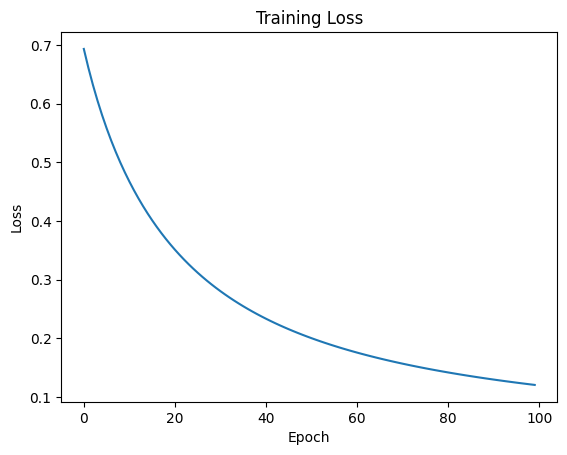

In [14]:
precision, recall, f1 = lr_model.evaluate(test_labels_lr, lr_predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")

lr_model.plot_loss()

### Assignment 2 (4 scores):

- Use Numpy only to construct the Softmax Regression model.
- Train and evaluating (precision, recall, f1) the Softmax Regression model using the Gradient Descent approach **to classify 10 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [15]:
class SoftmaxRegression:
    def __init__(self, learning_rate=0.5, epochs=300):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []

    @staticmethod
    def softmax(logits):
        shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(shifted_logits)
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-9
        return -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))

    @staticmethod
    def one_hot_encode(labels, num_classes):
        one_hot_labels = np.zeros((len(labels), num_classes))
        one_hot_labels[np.arange(len(labels)), labels] = 1
        return one_hot_labels

    def fit(self, features, labels):
        n_samples, n_features = features.shape
        num_classes = len(np.unique(labels))

        y_one_hot = self.one_hot_encode(labels, num_classes)

        self.weights = np.zeros((n_features, num_classes))
        self.bias = np.zeros(num_classes)

        for epoch in range(self.epochs):
            logits = np.dot(features, self.weights) + self.bias
            probabilities = self.softmax(logits)

            loss = self.compute_loss(y_one_hot, probabilities)
            self.losses.append(loss)

            dz = probabilities - y_one_hot
            dw = (1 / n_samples) * np.dot(features.T, dz)
            db = (1 / n_samples) * np.sum(dz, axis=0)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss {loss:.4f}")

    def predict(self, features):
        logits = np.dot(features, self.weights) + self.bias
        probabilities = self.softmax(logits)
        return np.argmax(probabilities, axis=1)

    def evaluate(self, y_true, y_pred):
        num_classes = len(np.unique(y_true))

        precisions = []
        recalls = []
        f1_scores = []

        for class_index in range(num_classes):
            true_positive = np.sum((y_true == class_index) & (y_pred == class_index))
            false_positive = np.sum((y_true != class_index) & (y_pred == class_index))
            false_negative = np.sum((y_true == class_index) & (y_pred != class_index))

            precision = true_positive / (true_positive + false_positive + 1e-9)
            recall = true_positive / (true_positive + false_negative + 1e-9)
            f1_score = 2 * precision * recall / (precision + recall + 1e-9)

            precisions.append(precision)
            recalls.append(recall)
            f1_scores.append(f1_score)

        return np.mean(precisions), np.mean(recalls), np.mean(f1_scores)

    def plot_loss(self):
        plt.plot(self.losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Softmax Training Loss")
        plt.show()

In [16]:
def preprocess_multiclass_data(images, labels):
    flattened_images = images.reshape(images.shape[0], -1)
    normalized_images = flattened_images / 255.0
    return normalized_images, labels


train_images_sr, train_labels_sr = preprocess_multiclass_data(
    train_images, train_labels
)
test_images_sr, test_labels_sr = preprocess_multiclass_data(test_images, test_labels)

In [17]:
print(
    f"train images: {train_images_sr.shape}, "
    f"train labels: {train_labels_sr.shape}"
)

print(
    f"test images: {test_images_sr.shape}, "
    f"test labels: {test_labels_sr.shape}"
)

train images: (60000, 784), train labels: (60000,)
test images: (10000, 784), test labels: (10000,)


In [18]:
softmax_model = SoftmaxRegression()
softmax_model.fit(train_images_sr, train_labels_sr)

Epoch 0, Loss 2.3026
Epoch 10, Loss 0.7815
Epoch 20, Loss 0.6021
Epoch 30, Loss 0.5288
Epoch 40, Loss 0.4869
Epoch 50, Loss 0.4592
Epoch 60, Loss 0.4390
Epoch 70, Loss 0.4236
Epoch 80, Loss 0.4113
Epoch 90, Loss 0.4012
Epoch 100, Loss 0.3926
Epoch 110, Loss 0.3853
Epoch 120, Loss 0.3790
Epoch 130, Loss 0.3734
Epoch 140, Loss 0.3684
Epoch 150, Loss 0.3639
Epoch 160, Loss 0.3599
Epoch 170, Loss 0.3562
Epoch 180, Loss 0.3528
Epoch 190, Loss 0.3497
Epoch 200, Loss 0.3468
Epoch 210, Loss 0.3442
Epoch 220, Loss 0.3417
Epoch 230, Loss 0.3394
Epoch 240, Loss 0.3372
Epoch 250, Loss 0.3351
Epoch 260, Loss 0.3332
Epoch 270, Loss 0.3314
Epoch 280, Loss 0.3297
Epoch 290, Loss 0.3280


In [19]:
softmax_predictions = softmax_model.predict(test_images_sr)
softmax_predictions

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

Precision: 0.9135
Recall: 0.9133
F1 score: 0.9132


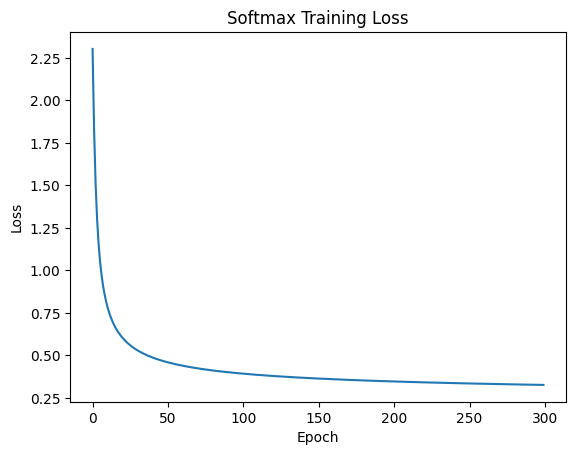

In [20]:
precision, recall, f1 = softmax_model.evaluate(
    test_labels_sr, softmax_predictions
)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")

softmax_model.plot_loss()

### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

In [22]:
sklearn_lr_model = LogisticRegression(max_iter=1000)
sklearn_lr_model.fit(train_images_lr, train_labels_lr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
lr_sklearn_predictions = sklearn_lr_model.predict(test_images_lr)

print("Confusion matrix:")
print(confusion_matrix(test_labels_lr, lr_sklearn_predictions))

print("Precision:", precision_score(test_labels_lr, lr_sklearn_predictions))
print("Recall:", recall_score(test_labels_lr, lr_sklearn_predictions))
print("F1:", f1_score(test_labels_lr, lr_sklearn_predictions))

Confusion matrix:
[[ 979    1]
 [   0 1135]]
Precision: 0.9991197183098591
Recall: 1.0
F1: 0.9995596653456627


In [28]:
softmax_sklearn_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
)

softmax_sklearn_model.fit(train_images_sr, train_labels_sr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
multiclass_predictions = softmax_sklearn_model.predict(test_images_sr)

print("Confusion matrix:")
print(confusion_matrix(test_labels_sr, multiclass_predictions))

print(
    "Precision:",
    precision_score(test_labels_sr, multiclass_predictions, average="macro"),
)
print(
    "Recall:",
    recall_score(test_labels_sr, multiclass_predictions, average="macro"),
)
print("F1:", f1_score(test_labels_sr, multiclass_predictions, average="macro"))

Confusion matrix:
[[ 957    0    1    4    1    9    4    3    1    0]
 [   0 1111    4    2    0    2    3    2   11    0]
 [   6    9  930   16   10    3   12    9   33    4]
 [   4    1   17  921    1   25    2   10   20    9]
 [   1    3    7    3  920    0    7    5    6   30]
 [   9    2    3   35    9  779   15    6   30    4]
 [   8    3    8    2    7   16  911    2    1    0]
 [   1    7   24    6    6    1    0  950    1   32]
 [  10   11    6   21    8   28   14    9  855   12]
 [   9    7    1    9   22    6    0   22    9  924]]
Precision: 0.9248108106415348
Recall: 0.924725670190816
F1: 0.924701282309413
